In [11]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Daytime vs Nighttime Population by County

In [4]:
# moved package imports above for simplified finding when writing requirements.txt

In [5]:
bay_area_lodes = pd.read_parquet("/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Data/bay_area_lodes_od_table.parquet")

In [6]:
bay_area_lodes.head()

,index,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03,work_county,home_county,work_tract,home_tract,within_tract
0,0,060014001001003,060014001002002,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001400100,True
1,1,060014001001003,060014001002018,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001400100,True
2,2,060014001001003,060014008001013,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001400800,False
3,3,060014001001003,060014010001004,1,0,1,0,0,0,1,0,0,1,06001,06001,06001400100,06001401000,False
4,4,060014001001003,060014016001025,1,0,0,1,0,0,1,0,0,1,06001,06001,06001400100,06001401600,False


In [7]:
#TODO: confirm there are extra counties because people who live OR work in bay area are counted
bay_area_lodes['home_county'].unique()

array(['06001', '06013', '06041', '06075', '06085', '06081', '06005',
       '06047', '06095', '06111', '06037', '06009', '06053', '06099',
       '06067', '06097', '06059', '06061', '06007', '06017', '06031',
       '06033', '06035', '06045', '06055', '06071', '06077', '06083',
       '06115', '06073', '06087', '06019', '06113', '06057', '06079',
       '06107', '06023', '06069', '06089', '06109', '06029', '06065',
       '06105', '06063', '06103', '06015', '06101', '06043', '06039',
       '06027', '06051', '06003', '06011', '06091', '06025', '06093',
       '06021', '06049'], dtype=object)

In [8]:
# group by county

county_pop = bay_area_lodes.groupby('work_county')['S000'].sum().to_frame().rename_axis("GEOID")
county_pop = county_pop.rename(columns = {"S000": "work_pop"}).rename_axis("GEOID")

county_pop["home_pop"] = bay_area_lodes.groupby("home_county")["S000"].sum()

# since those who either live or work in bay area are counted, filter this data for only those who live OR work in bay area.

bay_area_geocodes = ['06001', # Alameda
                     '06013', # Contra Costa
                     '06041', # Marin
                     '06055', # Napa
                     '06075', # SF
                     '06081', # San Mateo
                     '06085', # Santa Clara
                     '06095', # Solano
                     '06097'  # Sonoma
                     ]

bay_geocode_map = {'06001': 'Alameda',
                     '06013': 'Contra Costa',
                     '06041': 'Marin',
                     '06055': 'Napa',
                     '06075': 'San Francisco',
                     '06081': 'San Mateo',
                     '06085': 'Santa Clara',
                     '06095': 'Solano',
                     '06097': 'Sonoma',
                     }

county_pop = county_pop[county_pop.index.isin(bay_area_geocodes)]

county_pop['County'] = county_pop.index.map(bay_geocode_map)

county_pop


,work_pop,home_pop,County
GEOID,,,
06001,825618,801048,Alameda
06013,380441,520910,Contra Costa
06041,109755,107060,Marin
06055,75138,67312,Napa
06075,740480,441531,San Francisco
06081,420802,369299,San Mateo
06085,1131477,952232,Santa Clara
06095,138035,204544,Solano
06097,198140,217876,Sonoma


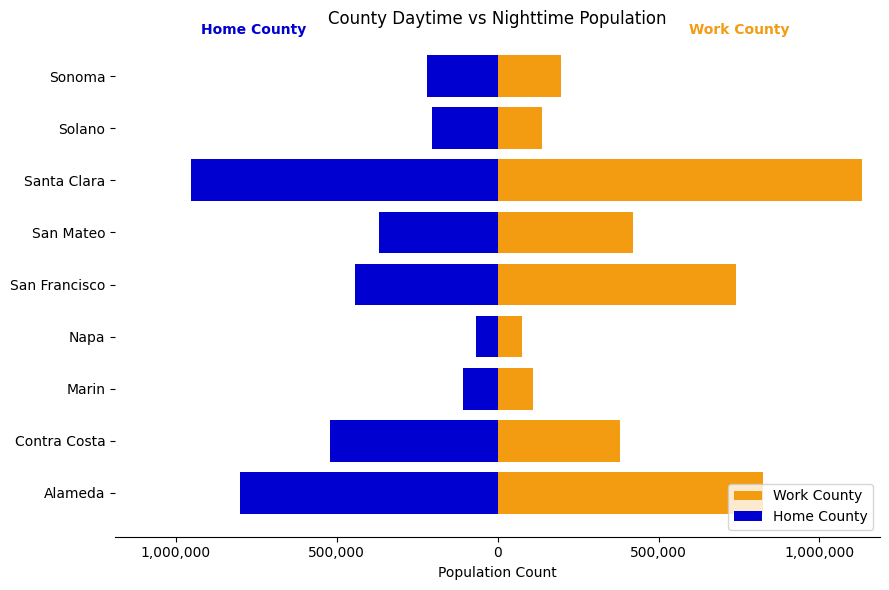

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

y = county_pop['County']

# use work and home populations for data in bar graph
ax.barh(y, width = county_pop['work_pop'], height = 0.8, color = '#f39c12', label = "Work County")
ax.barh(y, width = -county_pop['home_pop'], height = 0.8, color = '#0000D1', label = "Home County")

max_count = max(county_pop['home_pop'].max(), county_pop['work_pop'].max()) * 1.05 # * 1.05 adds 5% padding
ax.set_xlim(-max_count, max_count)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(abs(x)):,}'))

ax.text(-max_count * 0.5, 8.8, "Home County", fontweight = "bold", color = '#0000D1', ha='right')
ax.text(max_count * 0.5, 8.8, "Work County", fontweight = "bold", color = '#f39c12', ha='left')

ax.set_ylabel('')
ax.set_xlabel('Population Count')
ax.set_title('County Daytime vs Nighttime Population')
ax.spines[['top', 'right', 'left']].set_visible(False)

# Add legend
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

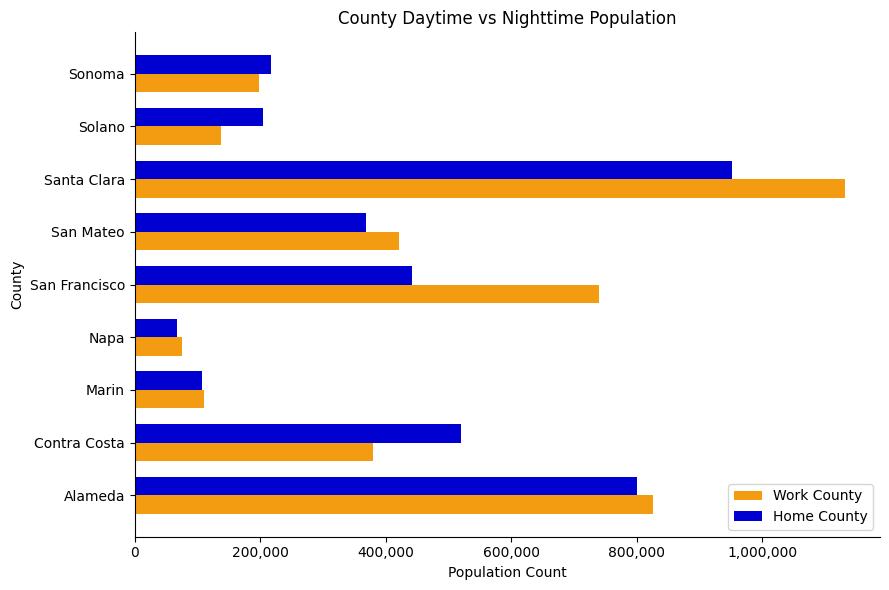

<Figure size 640x480 with 0 Axes>

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

y = county_pop['County']

y_pos = np.arange(len(y))
height = 0.35

ax.barh(y_pos - height/2, width = county_pop['work_pop'], height = height, color = '#f39c12', label = "Work County")
ax.barh(y_pos + height/2, width = county_pop['home_pop'], height = height, color = '#0000D1', label = "Home County")

ax.set_yticks(y_pos)
ax.set_yticklabels(y)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.set_ylabel('County')
ax.set_xlabel('Population Count')
ax.set_title('County Daytime vs Nighttime Population')
ax.spines[['top', 'right']].set_visible(False)

ax.legend(loc='lower right')

plt.tight_layout()
plt.show()



plt.savefig("/content/drive/MyDrive/Urban_Informatics_Final_Project/Colab/Visuals/day_night_pop.png")
